<a href="https://colab.research.google.com/github/vyenn/ML2024/blob/main/01_pytorch_workflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PyTorch Workflow

Let's explore an example PyTorch end-to-end workflow.

In [218]:
import torch
from torch import nn # nn containg all of PyTorch's building blocks for neural networks
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

what_were_covering = {1: "data (prepare and load)",
                      2: "build model",
                      3: "fitting the model to data (training)",
                      4: "making predictions and evaluating a model (inference)",
                      5: "saving and loading a model",
                      6: "putting it all together"}

## 1. Data (preparing and loading)

Let's create a *known* (to us) data using the linear regression formula.

In [219]:
weight = 0.7
bias = 0.3

# Create data
X = torch.arange(0, 1, 0.02).unsqueeze(dim=1)
y = weight * X + bias
X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

### Splitting data into training and test sets

In [220]:
# Create a train/test split
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(X_test)

(40, 10)

In [221]:
def plot_predictions(train_data=X_train, train_labels=y_train,
                     test_data = X_test, test_labels=y_test,
                     predictions = None):
  """
  Plots training data, test data and compares predictions.
  """

  plt.figure(figsize=(10,7))

  # Plot training data in blue
  plt.scatter(train_data, train_labels, c='b', s=4, label="Training data")

  # Plot test data in green
  plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

  # Predictions
  if predictions is not None:
    plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

  # Show the legend
  plt.legend(prop={"size": 14 })

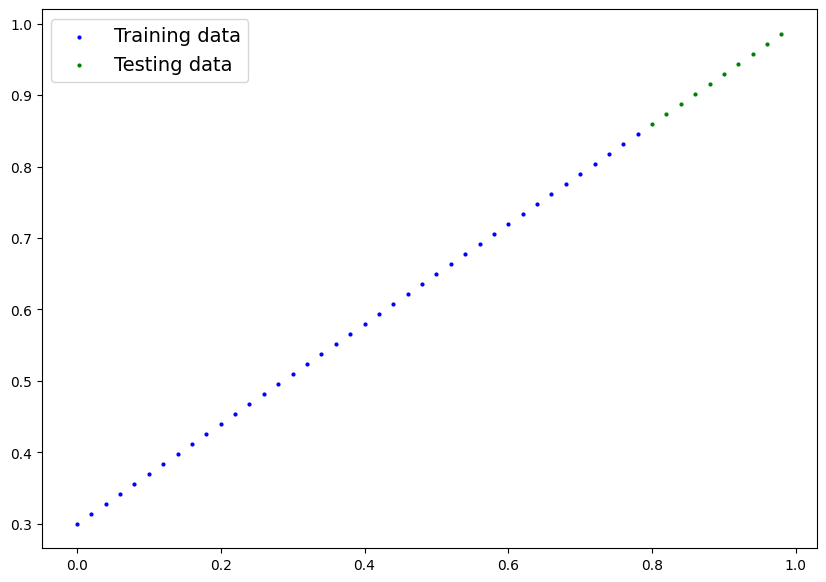

In [222]:
plot_predictions()

## Building a model

In [223]:
# Create a linear regression model class
class LinearRegressionModel(nn.Module): # our class inherits from nn.Module class
  def __init__(self):
    super().__init__()
    self.weights = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float))
    self.bias = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float))

  # Forward method to define the computation in the model
  def forward(self, x: torch.Tensor) -> torch.Tensor: # x is the input data
    return self.weights * x + self.bias

### PyTorch model building essentials

* torch.nn - contains all of the building for computational graphs (e.g. neural networks)
* torch.nn.Parameter - what parameters should our model try and learn, often a PyTorch layer from torch.nn will set these for us
* torch.nn.Module - the base class for all neural network modules. If you subclass it, you should overwrite forward()
* torch.optim - this is where the optimizers in PyTorch live - they will help with gradient descent



In [224]:
# We've created a model. Let's see what's inside...
torch.manual_seed(42)

model_0 = LinearRegressionModel()
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [225]:
# Listed named parameters
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

### Making predictions using `torch.inference_mode()`

When we pass data through our training model, it's gonna run it through a forward() method

In [226]:
# Make predictions with model
with torch.inference_mode():
  y_preds = model_0(X_test)

You could have just done
y_preds = model_0(X_test)
withouit inference_mode()...

what inference_mode() does, it disables all of the things that allow you
to train things. So if you just want to display and not train, use it to
keep track of less data.
inference (wnioskowanie) <--> prediction

See mode on inference mode here https://x.com/PyTorch/status/1437838231505096708?lang=en


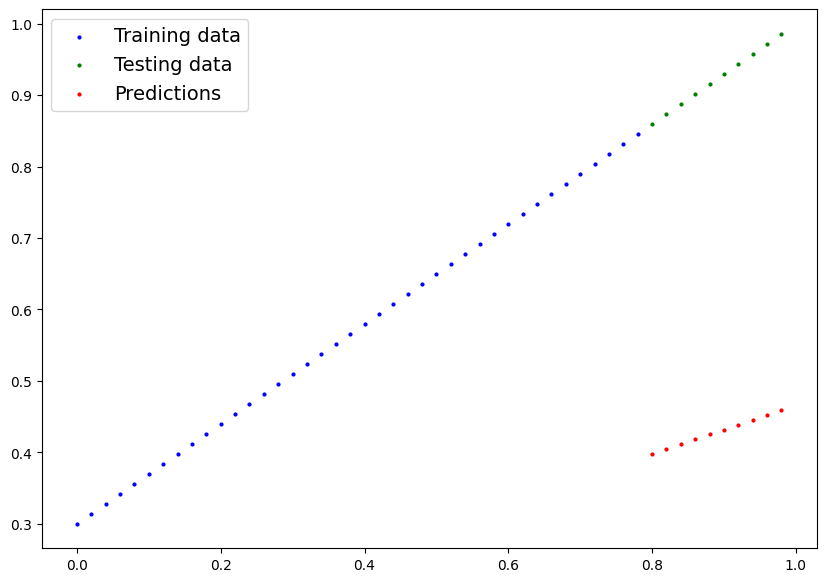

In [227]:
plot_predictions(predictions = y_preds)

## 3. Training a model

Things we need to train:

* **Loss function**
* **Optimizer**: takes into account the loss of a model and adjusts the model's parameters

And specifically in PyTorch we need:
* a training loop
* a testing loop

In [228]:
# Let's use L1 loss function
loss_fn = nn.MSELoss()

# Setup an optimizer (stochastic gradient descent)
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.01) # lr = learning rate

### Building a training and a testing loop

A couple of things we need in a training loop:

0. Loop through the data
1. Forward pass
2. Calculate the loss
3. Optimizer zero grad (**zero gradient value from previous loop iteration**)
4. Back propagation (**back propadation**)
5. Optimizer step (**gradient descent**)

In [229]:
# An epoch is one loop through the data...
epochs = 300

epoch_count = []
loss_values = []
test_loss_values = []

# 0. Loop through the data
for epoch in range(epochs):
  model_0.train() # train mode sets all parameters that require gradients to require them

  # 1. Forward pass
  y_pred = model_0(X_train)

  # 2. Calculate the loss
  loss = loss_fn(y_pred, y_train)

  # 3. Optimizer zero grad
  optimizer.zero_grad() # by deafult how the optimizer changes will accumulate trough the loop
                        # so we have to zero them here

  # 4. Back propagation
  loss.backward()

  # 5. Optimizer step
  optimizer.step()

  ### Testing
  model_0.eval() # turns off settings in the model not needed for evaluation (dropout, batch norm layers etc.)
  with torch.inference_mode(): # turns off gradient tracking and a bit more things not needed for testing
    # 1. do the forward pass
    test_pred = model_0(X_test)

    # 2. calculate the loss
    test_loss = loss_fn(test_pred, y_test)

    epoch_count.append(epoch)
    loss_values.append(loss)
    test_loss_values.append(test_loss)
  #if epoch % 10 == 0:
    #print(f"Epoch: {epoch} | Loss: {loss} | Test loss: {test_loss}")

model_0.eval() # turns off gradient tracking


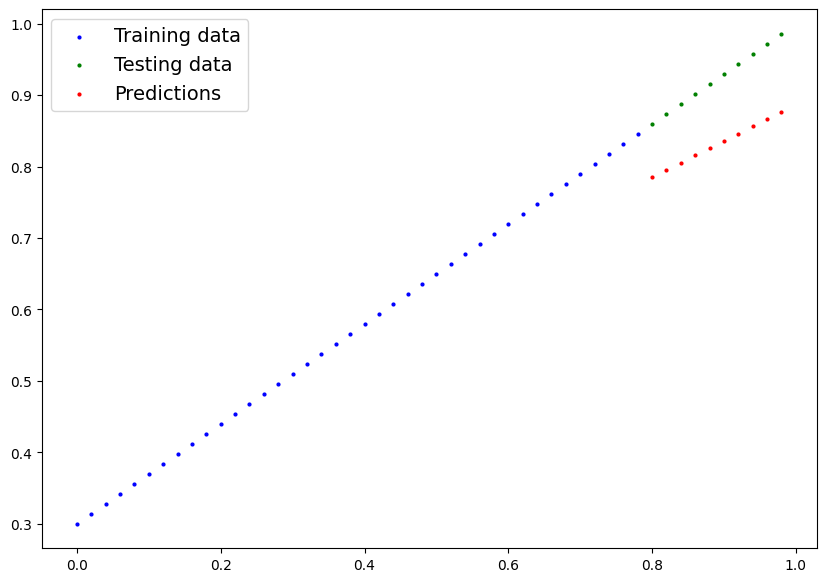

In [230]:
plot_predictions(predictions = model_0(X_test).detach())

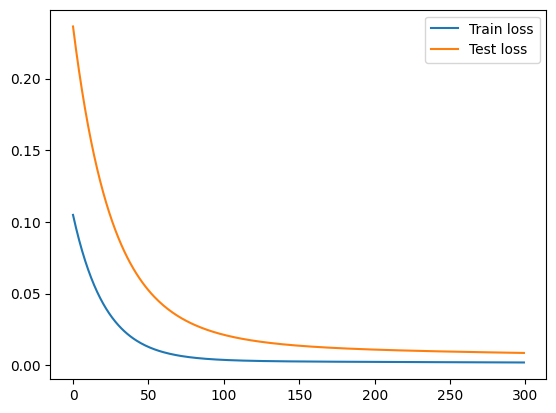

In [232]:
plt.plot(epoch_count, torch.tensor(loss_values).numpy(), label = "Train loss")
plt.plot(epoch_count, torch.tensor(test_loss_values).numpy(), label = "Test loss")
plt.legend()

## Saving a model in PyTorch

There are three main methods you should know about for saving and loading models in PyTorch.

1. `torch.save()` - allows you to save a PyTorch object in Python's pickle format

2. `torch.load()` - allows you to load a saved PyTorch object

3. `torch.nn.Module.load_state_dict()` - this allows you to load a model's saved state dictionary (recommended)

read at https://docs.pytorch.org/tutorials/beginner/saving_loading_models.html

In [235]:
# Saving our PyTorch model
from pathlib import Path

# 1. Creaty models directory (can do manually or with code)
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

# 2. Create model save path
MODEL_NAME = "01_pytorch_workflow_model_0.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# 3. Save the model's statedict
print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model_0.state_dict(), f=MODEL_SAVE_PATH)


Saving model to: models/01_pytorch_workflow_model_0.pth


## Loading a model